In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import os
import sys
import json
from sklearn.metrics import root_mean_squared_error
from ase.io import read, write
import numpy as np
import time
from mace.calculators import MACECalculator
from pymatgen.io.vasp.outputs import Vasprun
from pathlib import Path
from sklearn.metrics import root_mean_squared_error
from ase.io import read, write
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from pymatgen.core import Structure
from dscribe.descriptors import SOAP
from ase.build import molecule
from sklearn.decomposition import PCA

/storage/home/hcoda1/0/nwong70/.conda/envs/test_env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_in

In [26]:
# Figure Information
plt.style.use('default')
colors = ['#004488', "#BB5566", "#DDAA33", "#228833", "#7744AA", "#66CCEE"]
plt.rc('font', size=18)
plt.rc('axes', titlesize=22)
plt.rc('axes', labelsize=20)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=15)

In [3]:
class DFTInfo():
    def __init__(self, structure, forces, stress, energy, success=True):
        self.structure = structure
        self.forces = forces
        self.stress = stress
        self.energy = energy
        self.success = success
    def __str__(self):
        return self.structure, self.forces, self.energy
    def xyz_forces(self):
        if not self.success:
            return None
        arr = []
        for site, force in zip(self.structure.sites, self.forces):
            arr.append(np.concatenate([site.coords, force]))
        return np.array(arr)
    def from_json(cls, json_path):
        try:
            with open(json_path, "r") as f:
                data = json.load(f)
            structure = Structure.from_dict(data["structure"])
            forces = np.array(data["forces"])
            stress = np.array(data["stress"])
            energy = data["energy"]
            return cls(structure, forces, stress, energy, success=True)
        except Exception as e:
            print(f"Error reading JSON {json_path}: {e}")
            return cls(None, None, None, None, success=False)

In [4]:
def get_DFT_from_directory(dir_path):
    """ Takes in directory, reads in JSON files, and outputs dictionary of (timestep, DFTInfo)
    """
    frames = {}
    for fname in sorted(os.listdir(dir_path)):
        timestep = int(fname.split(".")[1])
        frames[timestep] = DFTInfo.from_json(DFTInfo, os.path.join(dir_path, fname + '/vasp_info.json'))
    return frames

# Models

In [22]:
# Universal Model
U_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:U/model/mace_agnesi_small.model")
# Naive Models
N_10pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-10pts/10pts.model", device='cuda')
N_21pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-21pts/21pts.model", device='cuda')
N_31pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-31pts/31pts.model", device='cuda')
N_40pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-40pts/40pts.model", device='cuda')
N_50pts_model = MACECalculator("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/50pts.model", device='cuda')
# Periodic Models
FT1_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT1/model/ft1.model")
FT2_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT2/model/ft2.model")
FT3_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT3/model/ft3.model")
FT4_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT4/model/ft4.model")
FT5_model = MACECalculator("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft5.model")


/storage/home/hcoda1/0/nwong70/.conda/envs/mace_updated/lib/python3.10/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f

Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.


/storage/home/hcoda1/0/nwong70/.conda/envs/mace_updated/lib/python3.10/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f

Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.


/storage/home/hcoda1/0/nwong70/.conda/envs/mace_updated/lib/python3.10/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f

...

/storage/home/hcoda1/0/nwong70/.conda/envs/mace_updated/lib/python3.10/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f

Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.


/storage/home/hcoda1/0/nwong70/.conda/envs/mace_updated/lib/python3.10/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f

Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['pt_head', 'Default']
No dtype selected, switching to float64 to match model dtype.


/storage/home/hcoda1/0/nwong70/.conda/envs/mace_updated/lib/python3.10/site-packages/mace/calculators/mace.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f

In [23]:
naive_models = [U_model, N_10pts_model, N_21pts_model, N_31pts_model, N_40pts_model, N_50pts_model]
periodic_models = [U_model, FT1_model, FT2_model, FT3_model, FT4_model, FT5_model]

# Evaluate Training Trajectories

### Read Data

In [22]:
U_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:U/dft")
FT1_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT1/dft")
FT2_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT2/dft")
FT3_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT3/dft")
FT4_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT4/dft")
FT5_Train_DFT = get_DFT_from_directory("../data/ChClCA_Finetuning/Periodic/Model:FT5/dft")
U_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:U/md/run_info.txt", sep = '\t')
FT1_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT1/md/run_info.txt", sep = '\t')
FT2_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT2/md/run_info.txt", sep = '\t')
FT3_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT3/md/run_info.txt", sep = '\t')
FT4_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT4/md/run_info.txt", sep = '\t')
FT5_Train_MD = pd.read_csv("../data/ChClCA_Finetuning/Periodic/Model:FT5/md/run_info.txt", sep = '\t')
training_DFT = [U_Train_DFT, FT1_Train_DFT, FT2_Train_DFT, FT3_Train_DFT, FT4_Train_DFT, FT5_Train_DFT]
training_MD = [U_Train_MD, FT1_Train_MD, FT2_Train_MD, FT3_Train_MD, FT4_Train_MD, FT5_Train_MD]

### Generate Plot

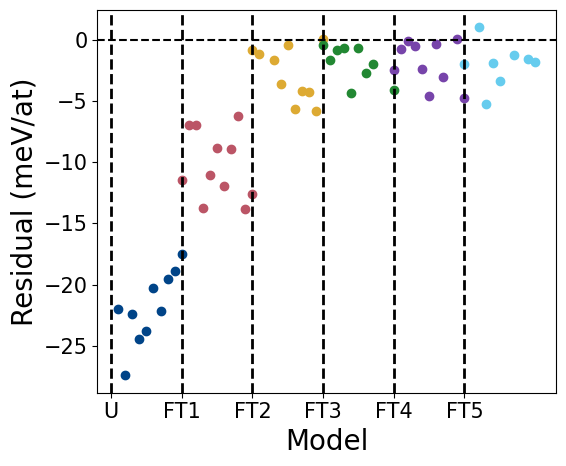

In [34]:
fig, ax = plt.subplots(figsize = (6, 5))
for idx, trajectory in enumerate(zip(training_DFT, training_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax.plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
ax.axhline(y=0, linestyle='--', color='black')
ax.axvline(x=1, linestyle='--', linewidth=2, color='black')
# ranges = [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]
# for (start, end), color in zip(ranges, colors):
#     ax.axvspan(start, end, alpha=0.3, color=color)
ax.axvline(x=2, linestyle='--', linewidth=2, color='black')
ax.axvline(x=3, linestyle='--', linewidth=2, color='black')
ax.axvline(x=4, linestyle='--', linewidth=2, color='black')
ax.axvline(x=5, linestyle='--', linewidth=2, color='black')
ax.axvline(x=6, linestyle='--', linewidth=2, color='black')
# ax.axvline(x=7, linestyle='--', linewidth=2, color='black')
ax.set_xticks(np.arange(1,7), ['U', 'FT1', 'FT2', 'FT3', 'FT4', 'FT5'])
ax.set_xlabel("Model")
ax.set_ylabel("Residual (meV/at)")
fig.tight_layout()
fig.savefig("./figures/trainingEvaluation.svg")

# Evaluate Test Sets

Allow each model to start from the same place, then we plot the difference in energy predictions

## Read Data

In [24]:
U_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/U/dft")
FT1_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT1/dft")
FT2_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT2/dft")
FT3_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT3/dft")
FT4_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT4/dft")
FT5_Eval_DFT =  get_DFT_from_directory("../data/ChClCA_Evaluations/Periodic/FT5/dft")
N_10pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-10pts/dft")
N_21pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-21pts/dft")
N_31pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-31pts/dft")
N_40pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-40pts/dft")
N_50pts_Eval_DFT = get_DFT_from_directory("../data/ChClCA_Evaluations/Naive/N-50pts/dft")
U_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/U/md/run_info.txt", sep='\t')
FT1_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT1/md/run_info.txt", sep='\t')
FT2_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT2/md/run_info.txt", sep='\t')
FT3_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT3/md/run_info.txt", sep='\t')
FT4_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT4/md/run_info.txt", sep='\t')
FT5_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Periodic/FT5/md/run_info.txt", sep='\t')
N_10pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-10pts/md/run_info.txt", sep='\t')
N_21pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-21pts/md/run_info.txt", sep='\t')
N_31pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-31pts/md/run_info.txt", sep='\t')
N_40pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-40pts/md/run_info.txt", sep='\t')
N_50pts_Eval_MD = pd.read_csv("../data/ChClCA_Evaluations/Naive/N-50pts/md/run_info.txt", sep='\t')


In [25]:
Naive_Eval_DFT = [U_Eval_DFT, N_10pts_Eval_DFT, N_21pts_Eval_DFT, N_31pts_Eval_DFT, N_40pts_Eval_DFT, N_50pts_Eval_DFT]
Naive_Eval_MD = [U_Eval_MD, N_10pts_Eval_MD, N_21pts_Eval_MD, N_31pts_Eval_MD, N_40pts_Eval_MD, N_50pts_Eval_MD]
Periodic_Eval_DFT = [U_Eval_DFT, FT1_Eval_DFT, FT2_Eval_DFT, FT3_Eval_DFT, FT4_Eval_DFT, FT5_Eval_DFT]
Periodic_Eval_MD = [U_Eval_MD, FT1_Eval_MD, FT2_Eval_MD, FT3_Eval_MD, FT4_Eval_MD, FT5_Eval_MD]

In [26]:
atoms = read("/storage/home/hcoda1/0/nwong70/r-jyang317-0/MACE_Finetuning_Repo/data/ChClCA_Evaluations/Periodic/FT5/md/FT5_ase.xyz", "::100")

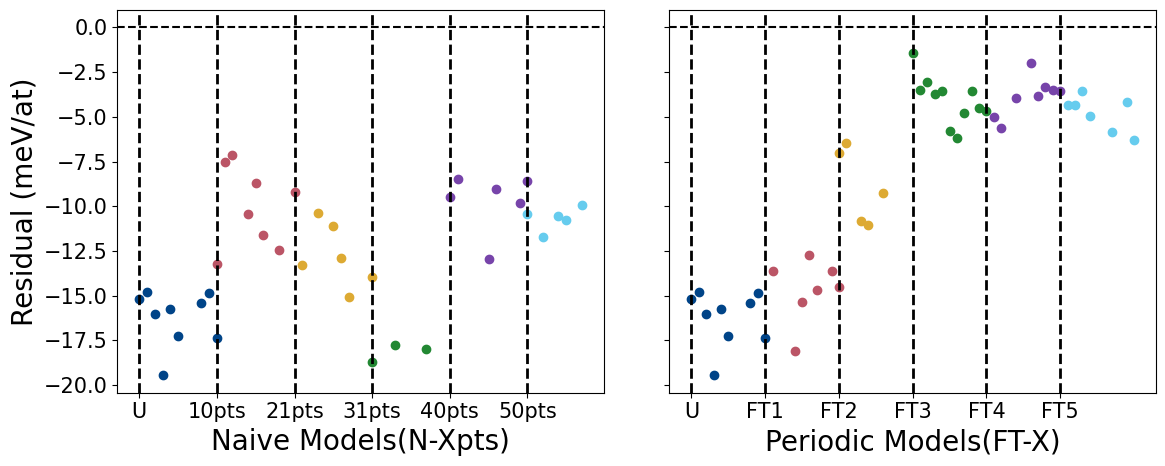

In [33]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5), sharey=True)
# Left plot, Naive
for idx, trajectory in enumerate(zip(Naive_Eval_DFT, Naive_Eval_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax[0].plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
# Right plot, Periodic
for idx, trajectory in enumerate(zip(Periodic_Eval_DFT, Periodic_Eval_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax[1].plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
ax[1].set_xticks(np.arange(1,7), ['U', 'FT1', 'FT2', 'FT3', 'FT4', 'FT5'])
ax[0].set_xticks(np.arange(1,7), ['U', '10pts', '21pts', '31pts', '40pts', '50pts'])
ax[0].axhline(y=0, linestyle='--', color='black')
ax[1].set_ylabel('   ')
ax[1].axhline(y=0, linestyle='--', color='black')
ax[0].axvline(x=1, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=2, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=3, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=4, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=5, linestyle='--', linewidth=2, color='black')
ax[0].axvline(x=6, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=1, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=2, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=3, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=4, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=5, linestyle='--', linewidth=2, color='black')
ax[1].axvline(x=6, linestyle='--', linewidth=2, color='black')
ax[0].set_xlabel("Naive Models(N-Xpts)")
ax[1].set_xlabel("Periodic Models(FT-X)")
ax[0].set_ylabel("Residual (meV/at)")
fig.tight_layout()
fig.savefig("./figures/modelEvaluations.svg")

In [11]:
U_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/U/dft")
FT1_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/FT1/dft")
FT2_Train_DFT =  get_DFT_from_directory("../data/LiClCoCl2_Finetuning/Periodic/FT2/dft")
U_Train_MD = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/U/md/run_info.txt", sep='\t')
FT1_Train_MD = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/FT1/md/run_info.txt", sep='\t')
FT2_Train_MD = pd.read_csv("../data/LiClCoCl2_Finetuning/Periodic/FT2/md/run_info.txt", sep='\t')
training_DFT = [U_Train_DFT, FT1_Train_DFT, FT2_Train_DFT]
training_MD = [U_Train_MD, FT1_Train_MD, FT2_Train_MD]



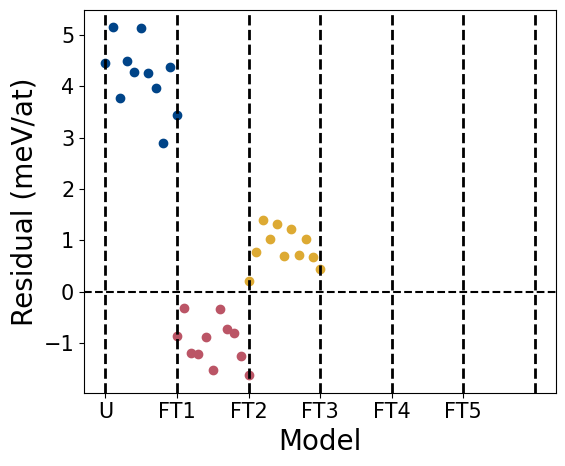

In [12]:
fig, ax = plt.subplots(figsize = (6, 5))
for idx, trajectory in enumerate(zip(training_DFT, training_MD)):
    diffs = {}
    for timestep in trajectory[0].keys():
        diff = (trajectory[1].iloc[timestep]['PotEng'] - trajectory[0][timestep].energy) * 1000 / 197
        diffs[timestep/1000+idx] = diff
    ax.plot(diffs.keys(), diffs.values(), 'o', color = colors[idx])
ax.axhline(y=0, linestyle='--', color='black')
ax.axvline(x=1, linestyle='--', linewidth=2, color='black')
# ranges = [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]
# for (start, end), color in zip(ranges, colors):
#     ax.axvspan(start, end, alpha=0.3, color=color)
ax.axvline(x=2, linestyle='--', linewidth=2, color='black')
ax.axvline(x=3, linestyle='--', linewidth=2, color='black')
ax.axvline(x=4, linestyle='--', linewidth=2, color='black')
ax.axvline(x=5, linestyle='--', linewidth=2, color='black')
ax.axvline(x=6, linestyle='--', linewidth=2, color='black')
ax.axvline(x=7, linestyle='--', linewidth=2, color='black')
ax.set_xticks(np.arange(1,7), ['U', 'FT1', 'FT2', 'FT3', 'FT4', 'FT5'])
ax.set_xlabel("Model")
ax.set_ylabel("Residual (meV/at)")
fig.tight_layout()

# SOAP/PCA Exploratory Data Analysis

In [5]:
naive_set = read("../data/ChClCA_Finetuning/Naive/Finetuned_Models/N-50pts/ft_dataset_raw.xyz", index=':')
ft_set = read("../data/ChClCA_Finetuning/Periodic/Model:FT5/model/ft4_data_raw.xyz", index=':')
all_data = naive_set + ft_set
species = set()
for atoms in all_data:
    species.update(atoms.get_chemical_symbols())
species = list(species)
soap = SOAP(
    species=species,
    r_cut=5,
    n_max=8,
    l_max=6,
    sigma=0.375,
    periodic=True,
    sparse=False
)

In [ ]:
# Generate SOAP
naive_desc = [soap.create(atoms, centers=atoms.get_positions()) for atoms in naive_set]
ft_desc   = [soap.create(atoms, centers=atoms.get_positions()) for atoms in ft_set]

# Convert to numpy arrays and flatten 
X_naive = np.array(naive_desc).reshape(-1, naive_desc[0].shape[-1])
X_ft   = np.array(ft_desc).reshape(-1, ft_desc[0].shape[-1])

# Combine for PCA fit
X_all = np.vstack([X_naive, X_ft])

# Fit PCA on combined data
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_all)

# Split back
X_naive_pca = X_pca[:len(X_naive)]
X_ft_pca   = X_pca[len(X_naive):]
explained_variance = pca.explained_variance_ratio_
print("Variance captured by each PC:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

# Cumulative variance
cumulative_variance = explained_variance.cumsum()
print("\nCumulative variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")


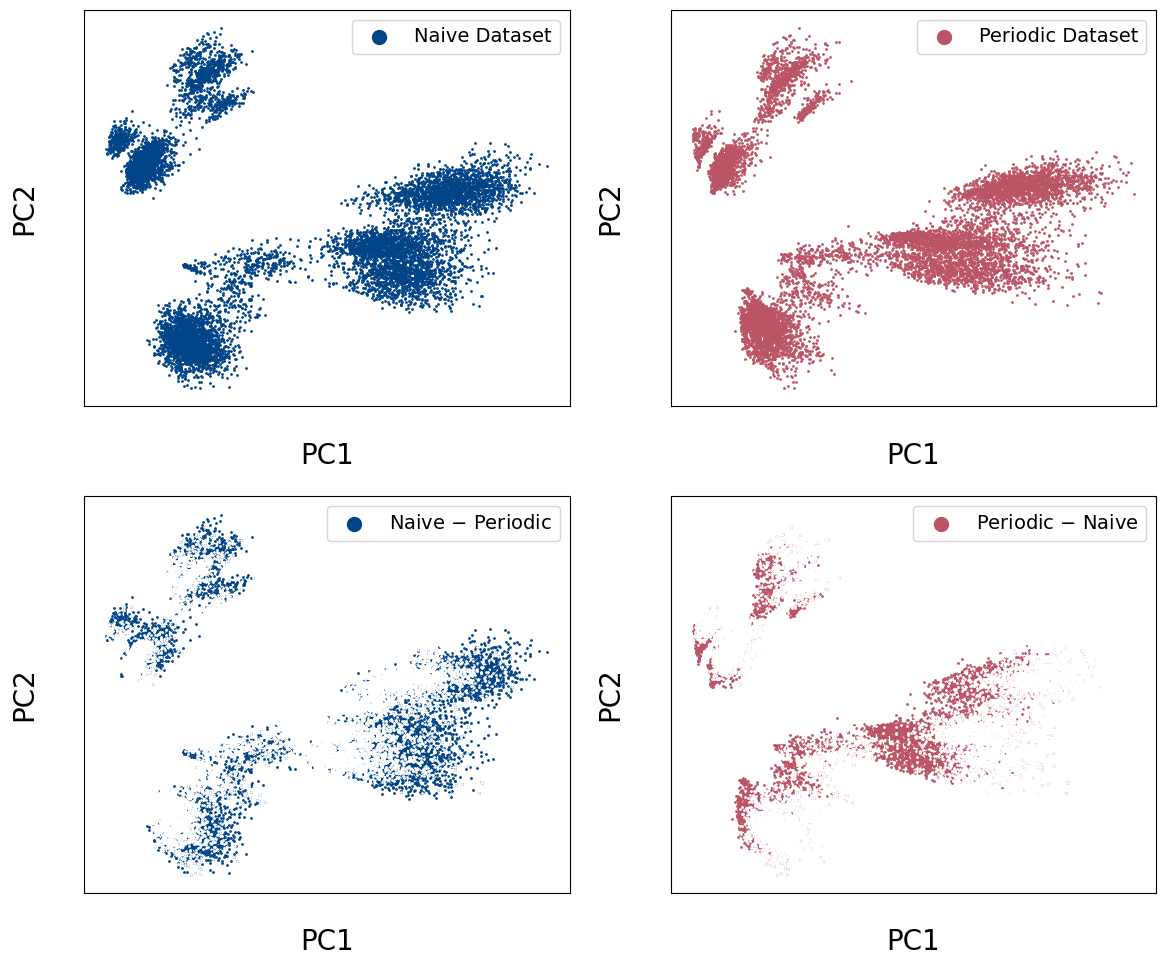

In [67]:
fig, ax = plt.subplots(2, 2, figsize = (12, 10), sharey=False)

ax[0,1].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color=colors[1], 
           label='Periodic Dataset', rasterized=True)
ax[0,0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color=colors[0], 
           label='Naive Dataset', rasterized=True)
ax[1,1].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color=colors[1], 
           label=r'Periodic $\minus$ Naive', rasterized=True)
ax[1,1].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
ax[1,0].scatter(X_naive_pca[:, 0], X_naive_pca[:, 1], s=1, alpha=1, color=colors[0], 
           label=r'Naive $\minus$ Periodic', rasterized=True)
ax[1,0].scatter(X_ft_pca[:, 0], X_ft_pca[:, 1], s=1, alpha=1, color='white', rasterized=True)
for a in ax[1]:
    # Make tick labels invisible but keep them in the layout
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
    # Make tick marks invisible but still exist
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
for a in ax[0]:
    # Make tick labels invisible but keep them in the layout
    a.tick_params(axis='both', which='both', labelcolor=(0,0,0,0))
    
    # Make tick marks invisible but still exist
    a.tick_params(axis='both', which='both', color=(0,0,0,0))
ax[1,1].set_xlabel("PC1")
ax[1,1].set_ylabel("PC2")
ax[1,0].set_xlabel("PC1")
ax[1,0].set_ylabel("PC2")
ax[0,1].set_xlabel("PC1")
ax[0,1].set_ylabel("PC2")
ax[0,0].set_xlabel("PC1")
ax[0,0].set_ylabel("PC2")
ax[1,1].legend(markerscale=10)
ax[1,0].legend(markerscale=10)
ax[0,0].legend(markerscale=10)
ax[0,1].legend(markerscale=10)
fig.tight_layout()
fig.savefig("figures/results_PCA_Datasets.svg")
